# 4_inter_intra_classification.ipynb

LOO = Leave-One-Campaign-Out
**Experiments:**
1. **Intra-campaign** - train/test on the same campaign, varying the training fraction.
2. **Inter-campaign (LOO)** - train on the other campaigns, test on the held-out target.

**Pipeline position:**  
Runs *after* classification sweep in `step_3_key_authors_graph` or `classification_sweep.ipynb`.

**Inputs:**   
One `accounts_graph...indicators.parquet` per campaig.
The parquet file is selected by the sweep-config parameters set below.
The table is author-level, indexed by `accountid`, and includes an `io_drive_label` column for the IO/non-IO ground truth.

**Outputs:**  
Results CSV, aggregated CSV, and performance plots for all scalar metrics.

# Imports

In [1]:
from __future__ import annotations

# File system
from pathlib import Path
import gc
import json
import time
import traceback

# Data
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# sklearn & models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

# Utilities
from functools import wraps

# Parameters

Papermill will inject values into the tagged cell below.
* `CAMPAIGNS` lists the campaigns to run the sweep over. 
* The `topic_method`, `edge_types`, `top_percentage`, and `graph_filtering_setting` values are used to build each campaign's exact `accounts_graph...indicators.parquet` file path. `top_percentage` uses the 1-100 scale, where 1 means 1%.

In [2]:
# Campaigns - each must have a completed step-3 sweep run at the standard location
CAMPAIGNS = ["Iran_1", "UAE", "Venezuela", "China_1", "Cuba", "Russia_1"]

output_dir = "../results/Labeled_Datasets/step_4_inter_intra_classification"

# Sweep configuration - used to build each campaign's exact indicator file path
graph_filtering_setting = "all_authors"  # "all_authors" or "graph_authors"
topic_method = "BERTopic_topic_256" # BERTopic_topic_128, K_Means_topic_124
edge_types = "similarity+text_similarity+interactions"
top_percentage = 100

# Training fractions are ratios in (0, 1], not graph-filter percentages.
FRACTIONS = [0.01, 0.05, 0.10, 0.25, 0.50, 1.0]

MODELS = ["xgboost", "random_forest", "logistic_regression"]

# Repeated once per seed in SEEDS, which re-seeds the sample and classifier.
# The 80/20 test split uses RANDOM_STATE and stays fixed across seeds.
SEEDS = [42, 123, 456, 789, 1024]

RANDOM_STATE = 42
TEST_SIZE    = 0.20

# Configuration

In [3]:
def validate_percentage(value: float | int, value_name: str) -> float:
    """Return a percentage after validating the shared 1-100 scale.

    Args:
        value: Percentage value from 1 through 100.
        value_name: Parameter name used in an error message.

    Returns:
        Validated percentage as a float.

    Raises:
        ValueError: If value is outside the inclusive range [1, 100].
    """
    percentage = float(value)
    if not 1 <= percentage <= 100:
        raise ValueError(
            f"{value_name} must be in [1, 100], where 1 means 1%; "
            f"got {value}."
        )
    return percentage

In [4]:
top_percentage = validate_percentage(top_percentage, "top_percentage")
CONFIG_TAG = (
    f"{graph_filtering_setting}_{topic_method}_{edge_types}"
    f"_top_percentage_{top_percentage:g}"
)


def build_indicator_path(campaign: str, graph_filtering_setting: str) -> Path:
    """Build a campaign's step-3 indicator file path from the sweep config.

    Args:
        campaign: Campaign name (matches its results directory name).
        graph_filtering_setting: Graph filtering setting (e.g., "all_authors" or "graph_authors").

    Returns:
        Path to the expected `classification_sweep_indicators` parquet file.
    """
    base_dir = Path(
        f"../results/Labeled_Datasets/{campaign}/{campaign}_part_all"
        f"/step_3_key_authors_graph/"
        # f"topic_col_{topic_method}_top_percentage_{top_percentage:g}/classification_sweep_indicators/"
        f"classification_sweep/classification_sweep_indicators/"
        f"{graph_filtering_setting}"
    )
    sweep_filename = (
        f"accounts_graph_{topic_method}_{edge_types}"
        f"_top_percentage_{top_percentage:g}_per_topic"
        f"_topic_col_{topic_method}_undirected_indicators.parquet"
    )
    return base_dir / sweep_filename


campaign_base_dirs = {campaign: build_indicator_path(campaign, graph_filtering_setting) for campaign in CAMPAIGNS}

print("Campaigns' paths:")
for campaign, path in campaign_base_dirs.items():
    print(f"  {campaign}: {path}")


for campaign, path in campaign_base_dirs.items():
    if not path.exists():
        raise FileNotFoundError(
            f"No data found for '{campaign}' at: {path}\n"
            f"Has the pipeline completed step 3 for this campaign?"
        )

Campaigns' paths:
  Iran_1: ../results/Labeled_Datasets/Iran_1/Iran_1_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic_256_undirected_indicators.parquet
  UAE: ../results/Labeled_Datasets/UAE/UAE_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic_256_undirected_indicators.parquet
  Venezuela: ../results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic_256_undirected_indicators.parquet
  China_1: ../results/Labeled_Datasets/Chin

# Logs

In [5]:
campaign_group_name = "_".join(
    sorted(campaign.lower().replace(" ", "_") for campaign in CAMPAIGNS)
)
output_path = Path(output_dir).expanduser() / campaign_group_name
output_path.mkdir(parents=True, exist_ok=True)
REPORT_PATH = output_path / "progress_report.txt"


def write_report(msg: str) -> None:
    """Write a timestamped message to stdout and the progress report.

    Args:
        msg: Message to write.
    """
    line = f"{time.strftime('%Y-%m-%d %H:%M:%S')} | {msg}"
    print(line)
    with open(REPORT_PATH, "a", encoding="utf-8") as report_file:
        report_file.write(line + "\n")


write_report(f"Campaign paths: {campaign_base_dirs}")
write_report(f"Output path: {output_path}")


def report_done(func):
    """Log completion or failure for a function.

    Args:
        func: Function to wrap.

    Returns:
        Wrapped function.
    """
    @wraps(func)
    def wrapper(*args, **kwargs):
        try:
            result = func(*args, **kwargs)
            write_report(f"Completed: {func.__name__}")
            return result
        except Exception as exc:
            write_report(f"FAILED: {func.__name__} | {exc}")
            raise
    return wrapper

2026-08-18 08:56:20 | Campaign paths: {'Iran_1': PosixPath('../results/Labeled_Datasets/Iran_1/Iran_1_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic_256_undirected_indicators.parquet'), 'UAE': PosixPath('../results/Labeled_Datasets/UAE/UAE_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic_256_undirected_indicators.parquet'), 'Venezuela': PosixPath('../results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic_256_undirected_in

# Classification

In [6]:
def get_classifier(model_name: str, random_state: int = RANDOM_STATE, **kwargs):
    """Return a sklearn-compatible classifier by name.

    Args:
        model_name: One of "xgboost"/"xgb", "random_forest"/"rf",
            "logistic_regression"/"lr".
        random_state: Random seed forwarded to the classifier constructor.
        **kwargs: Additional keyword arguments passed to the constructor.

    Returns:
        An untrained sklearn-compatible classifier instance.

    Raises:
        ValueError: If model_name is not recognised.
    """
    name = model_name.lower()
    if name in ("xgboost", "xgb"):
        return XGBClassifier(random_state=random_state, eval_metric="logloss", **kwargs)
    if name in ("random_forest", "rf"):
        return RandomForestClassifier(random_state=random_state, **kwargs)
    if name in ("logistic_regression", "lr"):
        return LogisticRegression(random_state=random_state, solver="liblinear", max_iter=1000, **kwargs)
    raise ValueError(
        f"Unsupported model_name: '{model_name}'. "
        "Supported: xgboost/xgb, random_forest/rf, logistic_regression/lr."
    )

# Data Loading

Each campaign in `campaign_base_dirs` points to one `classification_sweep_indicators.parquet` - An author-level feature DataFrame.  
Ground-truth labels are read from its `io_drive_label` column when present, 
or from step 3's
`io_author_analysis/io_authors_by_post_ratio.json`.

`load_country_data` loads one campaign's file. `load_multiple_campaigns` loads and
concatenates several campaigns (used for the LOO inter-campaign training pool).

In [7]:
def load_country_data(
    campaign_name: str,
    indicator_path: str | Path,
    prefix_ids: bool = True,
    normalize: bool = True,
    feature_columns: list[str] | None = None,
) -> tuple[pd.DataFrame, set]:
    """Load the node-indicator DataFrame and IO author set for one campaign.

    Args:
        campaign_name: Campaign label, used for logging and (if `prefix_ids`) as the
            `accountid` prefix.
        indicator_path: Path to the campaign's `classification_sweep_indicators`
            parquet file.
        prefix_ids: If True, prepend `"{campaign_name}_"` to every `accountid` so
            authors from different campaigns don't collide when concatenated.
        normalize: If True, min-max normalize numeric features separately for
            each campaign. Constant numeric columns are set to zero.
        feature_columns: Optional ordered feature list shared by all campaigns.

    Returns:
        df_features: Author-level DataFrame indexed by `accountid`, numeric columns
            only, ready for classification.
        io_set: Set of `accountid` strings labelled as IO.

    Raises:
        FileNotFoundError: If the indicator file doesn't exist.
        ValueError: If neither the parquet nor step 3 outputs provide labels.
    """
    campaign_name = campaign_name.strip()
    path = Path(indicator_path).expanduser()

    if not path.exists():
        raise FileNotFoundError(f"No indicator file for '{campaign_name}' at: {path}")

    df_features = pd.read_parquet(path)
    if "io_drive_label" in df_features.columns:
        io_labels = pd.to_numeric(
            df_features["io_drive_label"], errors="coerce"
        )
        io_set = set(df_features.index[io_labels.eq(1)].astype(str))
    else:
        step_3_dir = path.parents[3]
        label_paths = sorted(
            step_3_dir.glob(
                "topic_col_*/io_author_analysis/"
                "io_authors_by_post_ratio.json"
            )
        )
        if not label_paths:
            raise ValueError(
                f"'{path}' has no 'io_drive_label' column and no "
                f"io_author_analysis/io_authors_by_post_ratio.json "
                f"was found below '{step_3_dir}'."
            )
        with open(label_paths[0], encoding="utf-8") as label_file:
            io_set = set(map(str, json.load(label_file)))
        write_report(
            f"'{campaign_name}' has no embedded io_drive_label; "
            f"loaded labels from: {label_paths[0]}"
        )
    df_features = df_features.drop(
        columns=[
            "io_drive_label",
            "louvain_community",
            "top_topic",
            "boost_score",
        ],
        errors="ignore",
    )

    df_features = df_features.select_dtypes(include="number")
    if feature_columns is not None:
        missing_columns = sorted(set(feature_columns) - set(df_features.columns))
        if missing_columns:
            raise ValueError(
                f"'{campaign_name}' is missing shared features: {missing_columns}"
            )
        df_features = df_features[feature_columns].copy()

    if normalize:
        numeric_columns = df_features.select_dtypes(include="number").columns
        column_min = df_features[numeric_columns].min()
        column_range = (
            df_features[numeric_columns].max() - column_min
        ).replace(0, 1)
        df_features[numeric_columns] = (
            df_features[numeric_columns] - column_min
        ) / column_range

    if prefix_ids:
        df_features.index = campaign_name + "_" + df_features.index.astype(str)
        io_set = {f"{campaign_name}_{aid}" for aid in io_set}

    n_io_in_graph = len(set(df_features.index.astype(str)) & io_set)
    write_report(
        f"Loaded '{campaign_name}' ({path}) | {len(df_features)} authors in graph "
        f"| {len(io_set)} IO authors (dataset) | {n_io_in_graph} IO in graph"
    )
    return df_features, io_set


def load_multiple_campaigns(
    campaign_paths: dict[str, Path],
    feature_columns: list[str] | None = None,
) -> tuple[pd.DataFrame, set]:
    """Load and concatenate node-indicator data for several campaigns.

    Args:
        campaign_paths: Mapping from campaign name to its indicator file path.
        feature_columns: Optional ordered feature list shared by all campaigns.

    Returns:
        Combined author-level DataFrame (index prefixed with campaign name) and the
        union of all IO author sets.

    Raises:
        FileNotFoundError: If any campaign's file can't be loaded.
    """
    frames: list[pd.DataFrame] = []
    combined_io: set = set()

    for campaign_name, path in campaign_paths.items():
        df, io_set = load_country_data(
            campaign_name,
            path,
            prefix_ids=True,
            feature_columns=feature_columns,
        )
        frames.append(df)
        combined_io.update(io_set)

    return pd.concat(frames, axis=0), combined_io


def get_common_numeric_feature_columns(
    campaign_paths: dict[str, Path],
) -> list[str]:
    """Return numeric model features present in every campaign.

    Args:
        campaign_paths: Mapping from campaign name to its indicator file path.

    Returns:
        Ordered numeric feature names shared by all selected campaigns.
    """
    excluded_columns = {
        "io_drive_label",
        "louvain_community",
        "top_topic",
        "boost_score",
    }
    numeric_columns_by_campaign = {}
    for campaign_name, path in campaign_paths.items():
        campaign_df = pd.read_parquet(path)
        numeric_columns_by_campaign[campaign_name] = [
            column
            for column in campaign_df.select_dtypes(include="number").columns
            if column not in excluded_columns
        ]

    first_campaign = next(iter(campaign_paths))
    common_columns = set.intersection(
        *(set(columns) for columns in numeric_columns_by_campaign.values())
    )
    ordered_columns = [
        column
        for column in numeric_columns_by_campaign[first_campaign]
        if column in common_columns
    ]
    if not ordered_columns:
        raise ValueError("The selected campaigns have no numeric features in common.")

    return ordered_columns


def _stratified_sample(
    df: pd.DataFrame,
    io_str_set: set,
    n: int,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    """Sample n rows from df, guaranteeing at least 1 IO and 1 non-IO author.

    Args:
        df: Author-level DataFrame to sample from.
        io_str_set: Set of IO accountid strings (already prefixed if needed).
        n: Desired sample size (≥ 2).
        random_state: Random seed.

    Returns:
        Sampled DataFrame with at most *n* rows, both classes represented.
    """
    y         = df.index.astype(str).isin(io_str_set).astype(int)
    io_idx    = df.index[y == 1].tolist()
    nonIO_idx = df.index[y == 0].tolist()

    # If only one class is available, fall back to a plain sample
    if not io_idx or not nonIO_idx:
        return df.sample(n=min(n, len(df)), random_state=random_state)

    # Proportional allocation, minimum 1 of each class
    prop_io = len(io_idx) / len(df)
    n_io    = max(1, min(int(round(n * prop_io)), len(io_idx), n - 1))
    n_nonIO = max(1, min(n - n_io, len(nonIO_idx)))

    rng           = np.random.default_rng(random_state)
    sampled_io    = rng.choice(io_idx,    size=n_io,    replace=False).tolist()
    sampled_nonIO = rng.choice(nonIO_idx, size=n_nonIO, replace=False).tolist()

    return df.loc[sampled_io + sampled_nonIO]


In [8]:
# Use the same feature schema for every train/test campaign combination.
FEATURE_COLUMNS_USED = get_common_numeric_feature_columns(campaign_base_dirs)
write_report(
    f"Common feature columns used ({len(FEATURE_COLUMNS_USED)}): "
    f"{FEATURE_COLUMNS_USED}"
)
gc.collect()

2026-08-18 08:56:21 | Common feature columns used (10): ['degree_centrality', 'harmonic_centrality', 'eigenvector_centrality', 'betweenness_centrality', 'pagerank', 'core_number', 'clustering', 'key_score_sum', 'key_score_dominance', 'posting_dominance']


0

# Classification

In [ ]:
@report_done
def io_classification(
    node_indicators_df: pd.DataFrame,
    io_authors_set: set,
    model_name: str,
    test_size: float = TEST_SIZE,
    random_state: int = RANDOM_STATE,
    test_node_indicators_df: pd.DataFrame | None = None,
    test_io_authors_set: set | None = None,
) -> tuple:
    """Train and evaluate an IO classifier.

    Intra-campaign mode splits node_indicators_df internally; cross-campaign
    mode trains on it fully and evaluates on test_node_indicators_df /
    test_io_authors_set instead.

    Args:
        node_indicators_df: Training DataFrame, indexed by accountid.
        io_authors_set: IO accountid strings for the training data.
        model_name: Model identifier - see get_classifier.
        test_size: Held-out fraction for the intra-campaign split.
        random_state: Seed for splitting and the classifier.
        test_node_indicators_df: External test set for cross-campaign mode.
        test_io_authors_set: IO set matching test_node_indicators_df.

    Returns:
        tuple(clf, report, auc_roc, auc_pr, f1, recall, precision, y,
        y_proba), where f1, recall, and precision describe the positive
        IO class, and y contains the test labels.

    Raises:
        ValueError: Empty training set, or mismatched train/test columns.
    """
    if node_indicators_df.empty:
        raise ValueError("Training feature set is empty - aborting.")

    if test_node_indicators_df is not None and test_io_authors_set is None:
        raise ValueError(
            "test_node_indicators_df provided but test_io_authors_set is None. "
            "Both must be provided for cross-campaign mode."
        )

    if test_node_indicators_df is None and test_io_authors_set is not None:
        raise ValueError(
            "test_io_authors_set provided but test_node_indicators_df is None. "
            "Both must be provided for cross-campaign mode."
        )

    # Only numeric columns are used as model features
    train_numeric = node_indicators_df.select_dtypes(include="number")
    train_cols    = train_numeric.columns.tolist()
    X_train       = train_numeric.to_numpy()

    print(f"Training features ({len(train_cols)} columns): {train_cols}")

    io_str  = set(map(str, io_authors_set))
    y_train = node_indicators_df.index.astype(str).isin(io_str).astype(int)

    if len(np.unique(y_train)) < 2:
        raise ValueError(
            f"Training set has only one class ({np.unique(y_train)}). "
            "Cannot train a classifier."
        )

    # ── Cross-campaign mode ──────────────────────────────────────────────────
    if test_node_indicators_df is not None and test_io_authors_set is not None:
        write_report("Cross-campaign mode: using external test set.")

        test_numeric = test_node_indicators_df.select_dtypes(include="number")
        test_cols    = test_numeric.columns.tolist()

        print(f"Test features ({len(test_cols)} columns): {test_cols}")

        if train_cols != test_cols:
            mismatch = set(train_cols) ^ set(test_cols)
            raise ValueError(
                f"Train/test feature columns do not match.\n"
                f"Train cols: {len(train_cols)}  |  Test cols: {len(test_cols)}\n"
                f"Mismatched: {mismatch}"
            )

        X_test       = test_numeric.to_numpy()
        test_io_str  = set(map(str, test_io_authors_set))
        y_test       = test_node_indicators_df.index.astype(str).isin(test_io_str).astype(int)

    # ── Intra-campaign mode ──────────────────────────────────────────────────
    else:
        # stratify = y_train if len(np.unique(y_train)) > 1 else None
        X_train, X_test, y_train, y_test = train_test_split(
            X_train, y_train,
            test_size=test_size,
            random_state=random_state,
            stratify=y_train,
        )

    write_report(
        f"  [{model_name}] Train: {len(X_train)} | Test: {len(X_test)} "
        f"| IO in test: {int(y_test.sum())}"
    )

    clf = get_classifier(model_name=model_name, random_state=random_state)
    clf.fit(X_train, y_train)

    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]


    report = classification_report(
        y_test, y_pred, target_names=["Non-IO", "IO"], zero_division=0
    )

    auc_roc = roc_auc_score(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    precision = precision_score(y_test, y_pred, zero_division=0)
    y = np.asarray(y_test)

    return clf, report, auc_roc, auc_pr, f1, recall, precision, y, y_proba

# Experiment Sweep

In [ ]:
def run_experiment_sweep(
    campaigns: list[str],
    fractions: list[float],
    models: list[str],
    seeds: list[int],
    max_model_failures: int = 5,
) -> pd.DataFrame:
    """Run the full intra / LOO inter-campaign classification sweep, replicated
    across multiple seeds.

    For every target campaign the function:

    1. Loads the node-indicator DataFrame and IO set from `campaign_base_dirs`.
    2. Creates one **fixed 80 / 20 train/test split**, seeded by `RANDOM_STATE`.
    3. For each fraction and seed, draws a stratified intra sample and uses
       the same requested size for the LOO sample. If the LOO pool is smaller,
       that inter-campaign classification is skipped.
    4. Verifies zero overlap between the sampled train set and the test set.
    5. Runs **intra-campaign** and **LOO inter-campaign** experiments for every
       model. A single model/fraction/seed failure is logged with its traceback
       and doesn't stop the sweep - the sweep aborts once `max_model_failures`
       such failures accumulate.

    Args:
        campaigns: Campaign names - each must be a key in `campaign_base_dirs`.
        fractions: Training fractions to sweep, values in (0, 1].
        models: Model name strings passed to :func:`get_classifier`.
        seeds: Random seeds to replicate every (campaign, fraction, model,
            experiment_type) combination over.
        max_model_failures: Number of per-model/fraction/seed failures to
            tolerate before re-raising.

    Returns:
        DataFrame with columns:
        `training_campaign`, `target_campaign`, `graph_filtering_setting`,
        `train_fraction`, `model`, `experiment_type`, `train_size`, `seed`,
        `auc_roc`, `auc_pr`, `f1`, `recall`, `precision`, plus the
        serialized classifier, classification report, test labels, and
        predicted probabilities.

    Raises:
        FileNotFoundError: If a target or LOO campaign's data can't be loaded.
        ValueError: If a target campaign has no IO authors in its graph.
    """
    results: list[dict] = []
    n_model_failures = 0

    for target_camp in campaigns:
        write_report("=" * 60)
        write_report(f"Target campaign: {target_camp}")

        df_target, io_target = load_country_data(
            target_camp,
            campaign_base_dirs[target_camp],
            feature_columns=FEATURE_COLUMNS_USED,
        )

        io_target_str = set(map(str, io_target))
        y_all = df_target.index.astype(str).isin(io_target_str).astype(int)

        if y_all.sum() == 0:
            raise ValueError(
                f"No IO authors found for '{target_camp}'. "
                f"Check the io_drive_label column in: {campaign_base_dirs[target_camp]}"
            )

        # Fixed 80/20 train/test split.
        stratify = y_all
        df_train_full, df_test, y_train_full, y_test_ref = train_test_split(
            df_target, y_all,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            stratify=stratify,
        )
        test_io_set = set(df_test.index[y_test_ref == 1].astype(str))

        write_report(
            f"  Train pool: {len(df_train_full)} | Test: {len(df_test)} "
            f"| IO in test: {int(y_test_ref.sum())}"
        )

        # ── LOO: load and pool the other campaigns ──────────────────────
        loo_camps = [c for c in campaigns if c != target_camp]
        df_inter_all, io_inter_all = load_multiple_campaigns(
            {c: campaign_base_dirs[c] for c in loo_camps},
            feature_columns=FEATURE_COLUMNS_USED,
        )
        write_report(
            f"  LOO train pool: {len(df_inter_all)} authors from {loo_camps}"
        )

        # ── Fraction × seed × model sweep ─────────────────────────────
        for frac in fractions:
            n_intra = max(2, min(int(round(len(df_train_full) * frac)), len(df_train_full)))
            n_inter = n_intra
            skip_inter = len(df_inter_all) < n_inter
            if skip_inter:
                write_report(
                    f"  Skipping inter classification at {frac*100:.1f}%: "
                    f"LOO pool has {len(df_inter_all)} authors but {n_inter} "
                    "training examples are required."
                )

            for seed in seeds:
                # ── Intra: stratified sample from 80 % train pool, this seed ──
                if frac >= 1.0:
                    df_train_frac = df_train_full
                else:
                    df_train_frac = _stratified_sample(
                        df_train_full, io_target_str, n_intra, seed
                    )

                overlap = set(df_train_frac.index.astype(str)) & set(df_test.index.astype(str))
                assert len(overlap) == 0, (
                    f"FATAL: {len(overlap)} authors appear in both train and test sets "
                    f"for '{target_camp}' at fraction {frac}, seed {seed}!"
                )

                train_io_frac = set(df_train_frac.index.astype(str)) & io_target_str
                write_report(
                    f"  frac={frac*100:.1f}% seed={seed} | train_n={len(df_train_frac)} "
                    f"| IO_in_train={len(train_io_frac)}"
                )

                df_inter_frac = None
                inter_io_frac: set[str] = set()
                if not skip_inter:
                    if n_inter == len(df_inter_all):
                        df_inter_frac = df_inter_all
                    else:
                        df_inter_frac = _stratified_sample(
                            df_inter_all, set(map(str, io_inter_all)), n_inter, seed
                        )
                    inter_io_frac = (
                        set(df_inter_frac.index.astype(str))
                        & set(map(str, io_inter_all))
                    )

                for model_name in models:
                    # ─ Intra ─────────────────────────────────────────
                    try:
                        (
                            clf, report, auc_roc, auc_pr, f1, recall,
                            precision, y, y_proba,
                        ) = io_classification(
                            node_indicators_df=df_train_frac,
                            io_authors_set=train_io_frac,
                            model_name=model_name,
                            random_state=seed,
                            test_node_indicators_df=df_test,
                            test_io_authors_set=test_io_set,
                        )
                        results.append({
                            "training_campaign":       target_camp,
                            "target_campaign":         target_camp,
                            "graph_filtering_setting": graph_filtering_setting,
                            "train_fraction":          frac,
                            "model":                   model_name,
                            "experiment_type":         "intra",
                            "train_size":              len(df_train_frac),
                            "seed":                    seed,
                            "classifier":              repr(clf),
                            "classification_report":   report,
                            "auc_roc":                 auc_roc,
                            "auc_pr":                  auc_pr,
                            "f1":                      f1,
                            "recall":                  recall,
                            "precision":               precision,
                            "y":                       json.dumps(y.tolist()),
                            "y_proba":                 json.dumps(y_proba.tolist()),
                        })
                    except Exception:
                        n_model_failures += 1
                        write_report(
                            f"  ERROR intra | {target_camp} | {model_name} | "
                            f"frac={frac} | seed={seed} "
                            f"(failure {n_model_failures}/{max_model_failures})\n"
                            f"{traceback.format_exc()}"
                        )
                        if n_model_failures >= max_model_failures:
                            raise

                    if skip_inter:
                        continue

                    # ─ Inter (LOO) ────────────────────────────────
                    try:
                        (
                            clf, report, auc_roc, auc_pr, f1, recall,
                            precision, y, y_proba,
                        ) = io_classification(
                            node_indicators_df=df_inter_frac,
                            io_authors_set=inter_io_frac,
                            model_name=model_name,
                            random_state=seed,
                            test_node_indicators_df=df_test,
                            test_io_authors_set=test_io_set,
                        )
                        results.append({
                            "training_campaign":       ",".join(loo_camps),
                            "target_campaign":         target_camp,
                            "graph_filtering_setting": graph_filtering_setting,
                            "train_fraction":          frac,
                            "model":                   model_name,
                            "experiment_type":         "inter",
                            "train_size":              len(df_inter_frac),
                            "seed":                    seed,
                            "classifier":              repr(clf),
                            "classification_report":   report,
                            "auc_roc":                 auc_roc,
                            "auc_pr":                  auc_pr,
                            "f1":                      f1,
                            "recall":                  recall,
                            "precision":               precision,
                            "y":                       json.dumps(y.tolist()),
                            "y_proba":                 json.dumps(y_proba.tolist()),
                        })
                    except Exception:
                        n_model_failures += 1
                        write_report(
                            f"  ERROR inter | {target_camp} | {model_name} | "
                            f"frac={frac} | seed={seed} "
                            f"(failure {n_model_failures}/{max_model_failures})\n"
                            f"{traceback.format_exc()}"
                        )
                        if n_model_failures >= max_model_failures:
                            raise

        # Free memory before next campaign
        del df_target, df_train_full, df_inter_all
        gc.collect()

    return pd.DataFrame(results)

# Execution

In [11]:
write_report("Starting cross-campaign IO detection sweep.")
write_report(f"Campaigns  : {CAMPAIGNS}")
write_report(f"Training fractions (0-1 ratios): {FRACTIONS}")
write_report(f"Models     : {MODELS}")
write_report(f"Seeds      : {SEEDS}")
write_report(f"Graph filter: {graph_filtering_setting}")
write_report(f"Key-author selection percentage: {top_percentage:g}%")
write_report(f"Output dir : {output_path}")

results_df = run_experiment_sweep(
    campaigns=CAMPAIGNS,
    fractions=FRACTIONS,
    models=MODELS,
    seeds=SEEDS,
)

if results_df.empty:
    write_report(
        "WARNING: No results collected. "
        "Ensure all campaigns have completed step-3 sweep runs."
    )
else:
    write_report(f"Sweep complete - {len(results_df)} result rows collected.")
    display(results_df.head(12))


2026-08-18 08:56:21 | Starting cross-campaign IO detection sweep.
2026-08-18 08:56:21 | Campaigns  : ['Iran_1', 'UAE', 'Venezuela', 'China_1', 'Cuba', 'Russia_1']
2026-08-18 08:56:21 | Training fractions (0-1 ratios): [0.01, 0.05, 0.1, 0.25, 0.5, 1.0]
2026-08-18 08:56:21 | Models     : ['xgboost', 'random_forest', 'logistic_regression']
2026-08-18 08:56:21 | Seeds      : [42, 123, 456, 789, 1024]
2026-08-18 08:56:21 | Graph filter: all_authors
2026-08-18 08:56:21 | Key-author selection percentage: 100%
2026-08-18 08:56:21 | Output dir : ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela
2026-08-18 08:56:21 | ============================================================
2026-08-18 08:56:21 | Target campaign: Iran_1
2026-08-18 08:56:21 | 'Iran_1' has no embedded io_drive_label; loaded labels from: ../results/Labeled_Datasets/Iran_1/Iran_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/io_author_analys

,training_campaign,target_campaign,graph_filtering_setting,train_fraction,model,experiment_type,train_size,seed,classifier,classification_report,auc_roc,auc_pr,f1,recall,precision,y,y_proba
0,Iran_1,Iran_1,all_authors,0.01,xgboost,intra,45,42,"XGBClassifier(base_score=None, booster=None, c...",precision recall f1-score ...,0.959425,0.908143,0.888889,0.909091,0.869565,"[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.7755687832832336, 0.020042631775140762, 0.0..."
1,"UAE,Venezuela,China_1,Cuba,Russia_1",Iran_1,all_authors,0.01,xgboost,inter,45,42,"XGBClassifier(base_score=None, booster=None, c...",precision recall f1-score ...,0.966377,0.895063,0.015038,0.007576,1.000000,"[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.444378137588501, 0.0020491525065153837, 0.0..."
2,Iran_1,Iran_1,all_authors,0.01,random_forest,intra,45,42,RandomForestClassifier(random_state=42),precision recall f1-score ...,0.964542,0.931308,0.918699,0.856061,0.991228,"[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.92, 0.04, 0.0, 0.92, 0.02, 0.0, 0.0, 0.0, 0..."
3,"UAE,Venezuela,China_1,Cuba,Russia_1",Iran_1,all_authors,0.01,random_forest,inter,45,42,RandomForestClassifier(random_state=42),precision recall f1-score ...,0.957525,0.836044,0.588235,0.416667,1.000000,"[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.78, 0.17, 0.0, 0.69, 0.17, 0.0, 0.01, 0.0, ..."
4,Iran_1,Iran_1,all_authors,0.01,logistic_regression,intra,45,42,"LogisticRegression(max_iter=1000, random_state...",precision recall f1-score ...,0.946041,0.919263,0.307692,0.181818,1.000000,"[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.6712325665586574, 0.042047545588107596, 0.1..."
5,"UAE,Venezuela,China_1,Cuba,Russia_1",Iran_1,all_authors,0.01,logistic_regression,inter,45,42,"LogisticRegression(max_iter=1000, random_state...",precision recall f1-score ...,0.907444,0.787943,0.000000,0.000000,0.000000,"[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.29013755893597293, 0.04406597005005099, 0.0..."
6,Iran_1,Iran_1,all_authors,0.01,xgboost,intra,45,123,"XGBClassifier(base_score=None, booster=None, c...",precision recall f1-score ...,0.961902,0.850077,0.845528,0.787879,0.912281,"[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.739165186882019, 0.06768905371427536, 0.006..."
7,"UAE,Venezuela,China_1,Cuba,Russia_1",Iran_1,all_authors,0.01,xgboost,inter,45,123,"XGBClassifier(base_score=None, booster=None, c...",precision recall f1-score ...,0.920591,0.654731,0.767025,0.810606,0.727891,"[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5366525650024414, 0.0065261307172477245, 0...."
8,Iran_1,Iran_1,all_authors,0.01,random_forest,intra,45,123,RandomForestClassifier(random_state=123),precision recall f1-score ...,0.951468,0.910570,0.879668,0.803030,0.972477,"[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.92, 0.0, 0.01, 0.97, 0.02, 0.09, 0.0, 0.13,..."
9,"UAE,Venezuela,China_1,Cuba,Russia_1",Iran_1,all_authors,0.01,random_forest,inter,45,123,RandomForestClassifier(random_state=123),precision recall f1-score ...,0.961423,0.890129,0.516854,0.348485,1.000000,"[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.62, 0.25, 0.07, 0.46, 0.27, 0.0, 0.15, 0.04..."


# Save Results

In [12]:
if not results_df.empty:
    csv_path = output_path / f"experiment_results_{CONFIG_TAG}.csv"
    results_df.to_csv(csv_path, index=False)
    write_report(f"Results saved → {csv_path}")
    display(results_df.describe())

    # ── Seed-aggregated summary (mean/std across the SEEDS replicates) ────────
    agg_path = output_path / f"experiment_results_{CONFIG_TAG}_aggregated.csv"
    results_agg = (
        results_df
        .groupby(["target_campaign", "experiment_type", "model", "train_fraction"])
        .agg(
            auc_roc_mean=("auc_roc", "mean"),
            auc_roc_std=("auc_roc", "std"),
            auc_pr_mean=("auc_pr", "mean"),
            auc_pr_std=("auc_pr", "std"),
            f1_mean=("f1", "mean"),
            f1_std=("f1", "std"),
            recall_mean=("recall", "mean"),
            recall_std=("recall", "std"),
            precision_mean=("precision", "mean"),
            precision_std=("precision", "std"),
            train_size=("train_size", "first"),
            n_seeds=("seed", "nunique"),
        )
        .reset_index()
    )
    results_agg.to_csv(agg_path, index=False)
    write_report(f"Seed-aggregated results saved → {agg_path}")
    display(results_agg.head(12))

2026-08-18 09:07:35 | Results saved → ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100.csv


,train_fraction,train_size,seed,auc_roc,auc_pr,f1,recall,precision
count,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000
mean,0.318333,5867.583333,486.800000,0.943856,0.803418,0.688175,0.649304,0.821254
std,0.345868,8191.827782,377.283393,0.054583,0.224795,0.266474,0.242675,0.275134
min,0.010000,45.000000,42.000000,0.727448,0.039023,0.000000,0.000000,0.000000
25%,0.050000,539.500000,123.000000,0.917512,0.762474,0.528857,0.471548,0.825839
50%,0.175000,2359.000000,456.000000,0.961534,0.890883,0.787678,0.693069,0.945005
75%,0.500000,7259.500000,789.000000,0.986325,0.945056,0.892308,0.851485,0.986933
max,1.000000,34255.000000,1024.000000,0.999673,0.996225,0.990000,0.980198,1.000000


2026-08-18 09:07:35 | Seed-aggregated results saved → ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_aggregated.csv


,target_campaign,experiment_type,model,train_fraction,auc_roc_mean,auc_roc_std,auc_pr_mean,auc_pr_std,f1_mean,f1_std,recall_mean,recall_std,precision_mean,precision_std,train_size,n_seeds
0,China_1,inter,logistic_regression,0.01,0.834152,0.024017,0.286611,0.064976,0.296419,0.057069,0.305714,0.071856,0.310819,0.103434,343,5
1,China_1,inter,logistic_regression,0.05,0.832755,0.013948,0.300098,0.039103,0.225282,0.030757,0.441429,0.043566,0.151666,0.024665,1713,5
2,China_1,inter,logistic_regression,0.10,0.798641,0.009301,0.240728,0.024920,0.175006,0.009048,0.411429,0.026049,0.111264,0.006637,3426,5
3,China_1,inter,logistic_regression,0.25,0.769813,0.012811,0.180185,0.012287,0.129684,0.012811,0.434286,0.035138,0.076271,0.008055,8564,5
4,China_1,inter,logistic_regression,0.50,0.743534,0.007886,0.145987,0.005663,0.104007,0.004232,0.430000,0.032498,0.059167,0.002146,17128,5
5,China_1,inter,logistic_regression,1.00,0.731609,0.002377,0.127005,0.003999,0.096676,0.001729,0.442857,0.011294,0.054262,0.000964,34255,5
6,China_1,inter,random_forest,0.01,0.863633,0.019619,0.368699,0.105323,0.370234,0.138352,0.398571,0.124171,0.452944,0.237907,343,5
7,China_1,inter,random_forest,0.05,0.857464,0.018126,0.304681,0.052246,0.287370,0.050714,0.465714,0.055650,0.214078,0.057000,1713,5
8,China_1,inter,random_forest,0.10,0.838930,0.012758,0.262843,0.067761,0.252962,0.061216,0.367143,0.063608,0.196979,0.066425,3426,5
9,China_1,inter,random_forest,0.25,0.835143,0.014790,0.182252,0.043509,0.157541,0.037831,0.371429,0.065270,0.102674,0.032858,8564,5


# Plots

One row per model and one column per campaign. Each subplot compares
intra-campaign (gold) with leave-one-out training (blue). Inter training
uses the intra sample size; classifications are skipped when the available
LOO pool is smaller.

In [13]:
LINES = [
    ("intra", "Intra Campaign", "#D4A017", "o"),  # gold/orange, circle
    ("inter", "Leave One Out", "#4472C4", "s"),  # blue, square
]

CAMPAIGN_ORDER = list(campaign_base_dirs.keys())


def plot_cross_campaign_performance(
    df_results: pd.DataFrame,
    metric: str,
    output_dir: Path | None = None,
) -> None:
    """Plot intra- vs inter-campaign performance.

    Produces one row per model and one column per campaign. Each subplot
    shows intra-campaign and inter-campaign LOO means with ±1 standard
    deviation across seeds, clipped to ``[0, 1]``.

    Args:
        df_results: Output of the experiment sweep.  Must contain columns
            ``target_campaign``, ``experiment_type``, ``train_fraction``,
            and the requested *metric* column.
        metric: Scalar metric column to visualise, such as ``"auc_roc"``
            or ``"f1"``.
        output_dir: Directory to save the PNG at 600 dpi.  Not saved if
            ``None``.
    """
    expected_train_sizes = (
        df_results[df_results["experiment_type"] == "intra"]
        .groupby(["target_campaign", "train_fraction"])["train_size"]
        .max()
        .rename("expected_train_size")
        .reset_index()
    )
    plot_results = df_results.merge(
        expected_train_sizes,
        on=["target_campaign", "train_fraction"],
        how="left",
    )
    undersized_inter = (
        (plot_results["experiment_type"] == "inter")
        & (plot_results["train_size"] < plot_results["expected_train_size"])
    )
    if undersized_inter.any():
        write_report(
            f"Excluding {int(undersized_inter.sum())} capped LOO results from the plot."
        )
        plot_results = plot_results[~undersized_inter].copy()

    campaigns = [
        campaign
        for campaign in CAMPAIGN_ORDER
        if campaign in plot_results["target_campaign"].unique()
    ]
    if not campaigns:
        write_report(f"No data to plot for metric '{metric}'.")
        return

    models = [model for model in MODELS if model in plot_results["model"].unique()]
    if not models:
        write_report(f"No model data to plot for metric '{metric}'.")
        return

    nrows = len(models)
    ncols = len(campaigns)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(9 * ncols, 7 * nrows),
        dpi=150,
        squeeze=False,
        sharex=False,
        sharey=True,
    )

    for row_index, model_name in enumerate(models):
        for column_index, camp in enumerate(campaigns):
            ax = axes[row_index, column_index]
            subset_model = plot_results[
                (plot_results["target_campaign"] == camp)
                & (plot_results["model"] == model_name)
            ]

            for exp_type, label, color, marker in LINES:
                subset = subset_model[subset_model["experiment_type"] == exp_type]
                if subset.empty:
                    continue
                grouped = (
                    subset.groupby("train_fraction")
                    .agg(
                        mean=(metric, "mean"),
                        std=(metric, "std"),
                        train_size=("train_size", "mean"),
                    )
                    .reset_index()
                )
                mean = grouped["mean"]
                std = grouped["std"].fillna(0)
                training_percentage = grouped["train_fraction"] * 100
                lower = np.maximum(mean - std, 0.0)
                upper = np.minimum(mean + std, 1.0)
                yerr = np.vstack([mean - lower, upper - mean])
                ax.errorbar(
                    training_percentage,
                    mean,
                    yerr=yerr,
                    fmt=f"-{marker}",
                    color=color,
                    label=label,
                    capsize=3,
                    linewidth=1.5,
                    markersize=6,
                    elinewidth=1.0,
                )

            training_percentages = sorted(
                plot_results["train_fraction"].dropna().unique() * 100
            )
            ax.set_xticks(training_percentages)
            ax.set_xticklabels([f"{percentage:g}%" for percentage in training_percentages])
            ax.set_ylim(0, 1.05)
            ax.set_title(
                camp,
                fontweight="bold",
                fontsize=19,
            )
            ax.set_xlabel(
                "Percentage of traning Data",
                fontsize=18,
                labelpad=12,
            )
            ax.set_ylabel(metric.upper(), fontsize=18, labelpad=10)
            ax.tick_params(
                axis="both",
                labelsize=16,
                labelbottom=True,
                labelleft=True,
                pad=6,
            )
            ax.legend(
                title=model_name.replace("_", " ").title(),
                fontsize=16,
                title_fontsize=16,
                loc="lower right",
            )
            ax.grid(True, linestyle="--", alpha=0.4)

    # ── Figure-level title, layout, and save ──────────────────────────────────
    fig.suptitle(
        "IO Classification\n"
        f"Campaign Group: [{', '.join(campaigns)}]",
        fontsize=22,
        fontweight="bold",
    )
    fig.text(
        0.5,
        0.01,
        "\nLOO = Leave-One-Out.\n"
        f"Test split is {TEST_SIZE*100:.0f}% from target campaign.\n"
        "Intra-campaign: the model is trained on sampled authors from the target train split and evaluated on target campaign test split.\n"
        "LOO: the model is trained on an samples pooled from all other campaigns and evaluated on target campaign test split.\n"
        "Each subplot title is the target campaign, and the legend title is the classifier used.\n"
        "If the LOO training pool is smaller than the target campaign's training pool, some classification is skipped.\n",
        ha="center",
        va="bottom",
        fontsize=18,
    )
    note_margin = min(0.32, 2.2 / fig.get_figheight())
    plt.tight_layout(rect=[0, note_margin, 1, 0.94], h_pad=3.0, w_pad=2.5)
    if output_dir:
        out_path = output_dir / f"experiment_results_{CONFIG_TAG}_strategy_comparison_{metric}.png"
        plt.savefig(out_path, dpi=600, bbox_inches="tight")
        write_report(f"Saved plot → {out_path}")
    plt.show()

2026-08-18 09:07:57 | Saved plot → ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_strategy_comparison_auc_roc.png


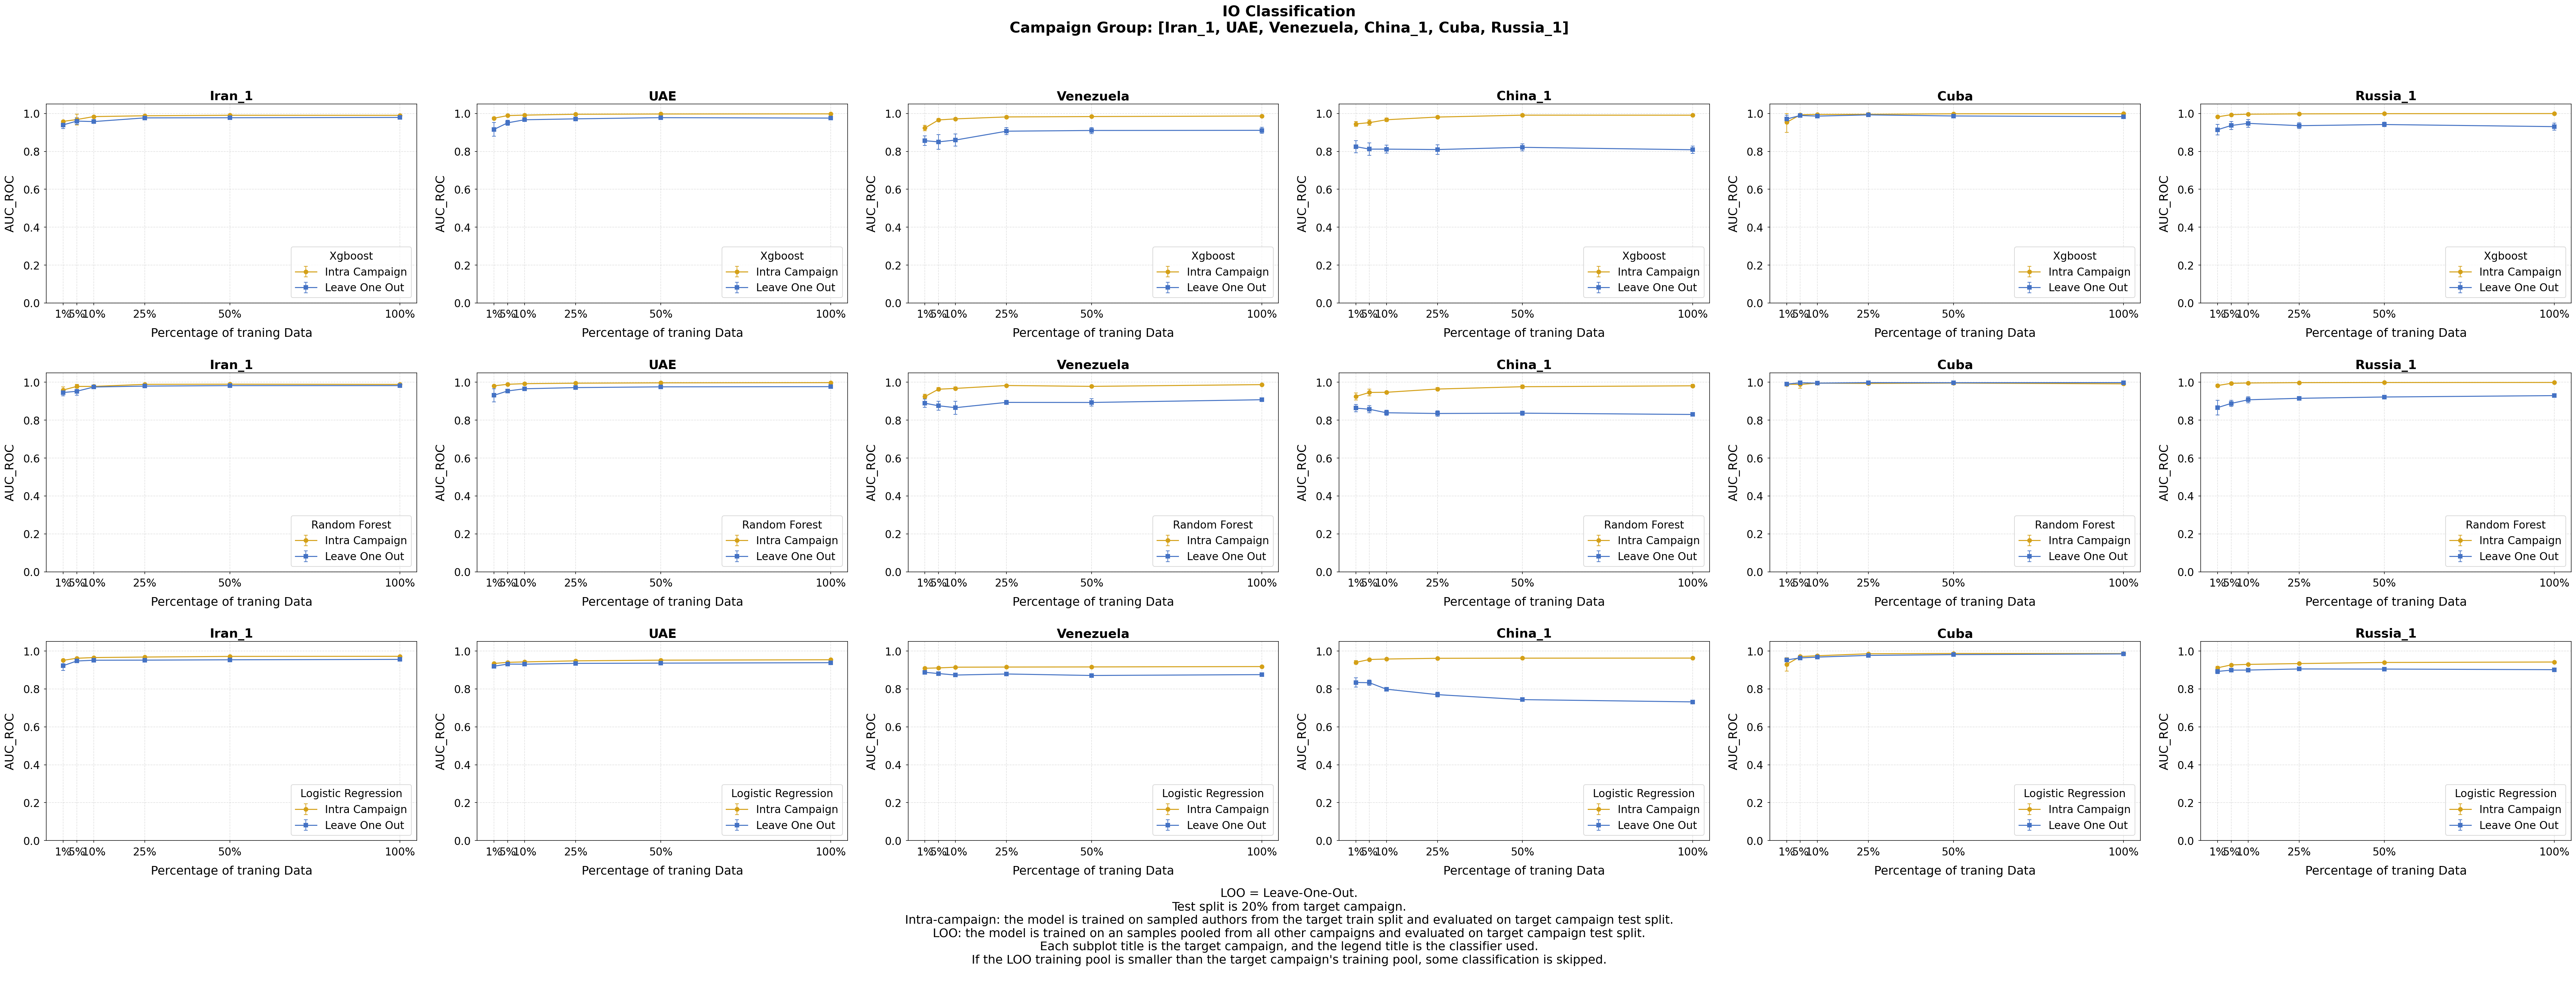

2026-08-18 09:08:21 | Saved plot → ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_strategy_comparison_auc_pr.png


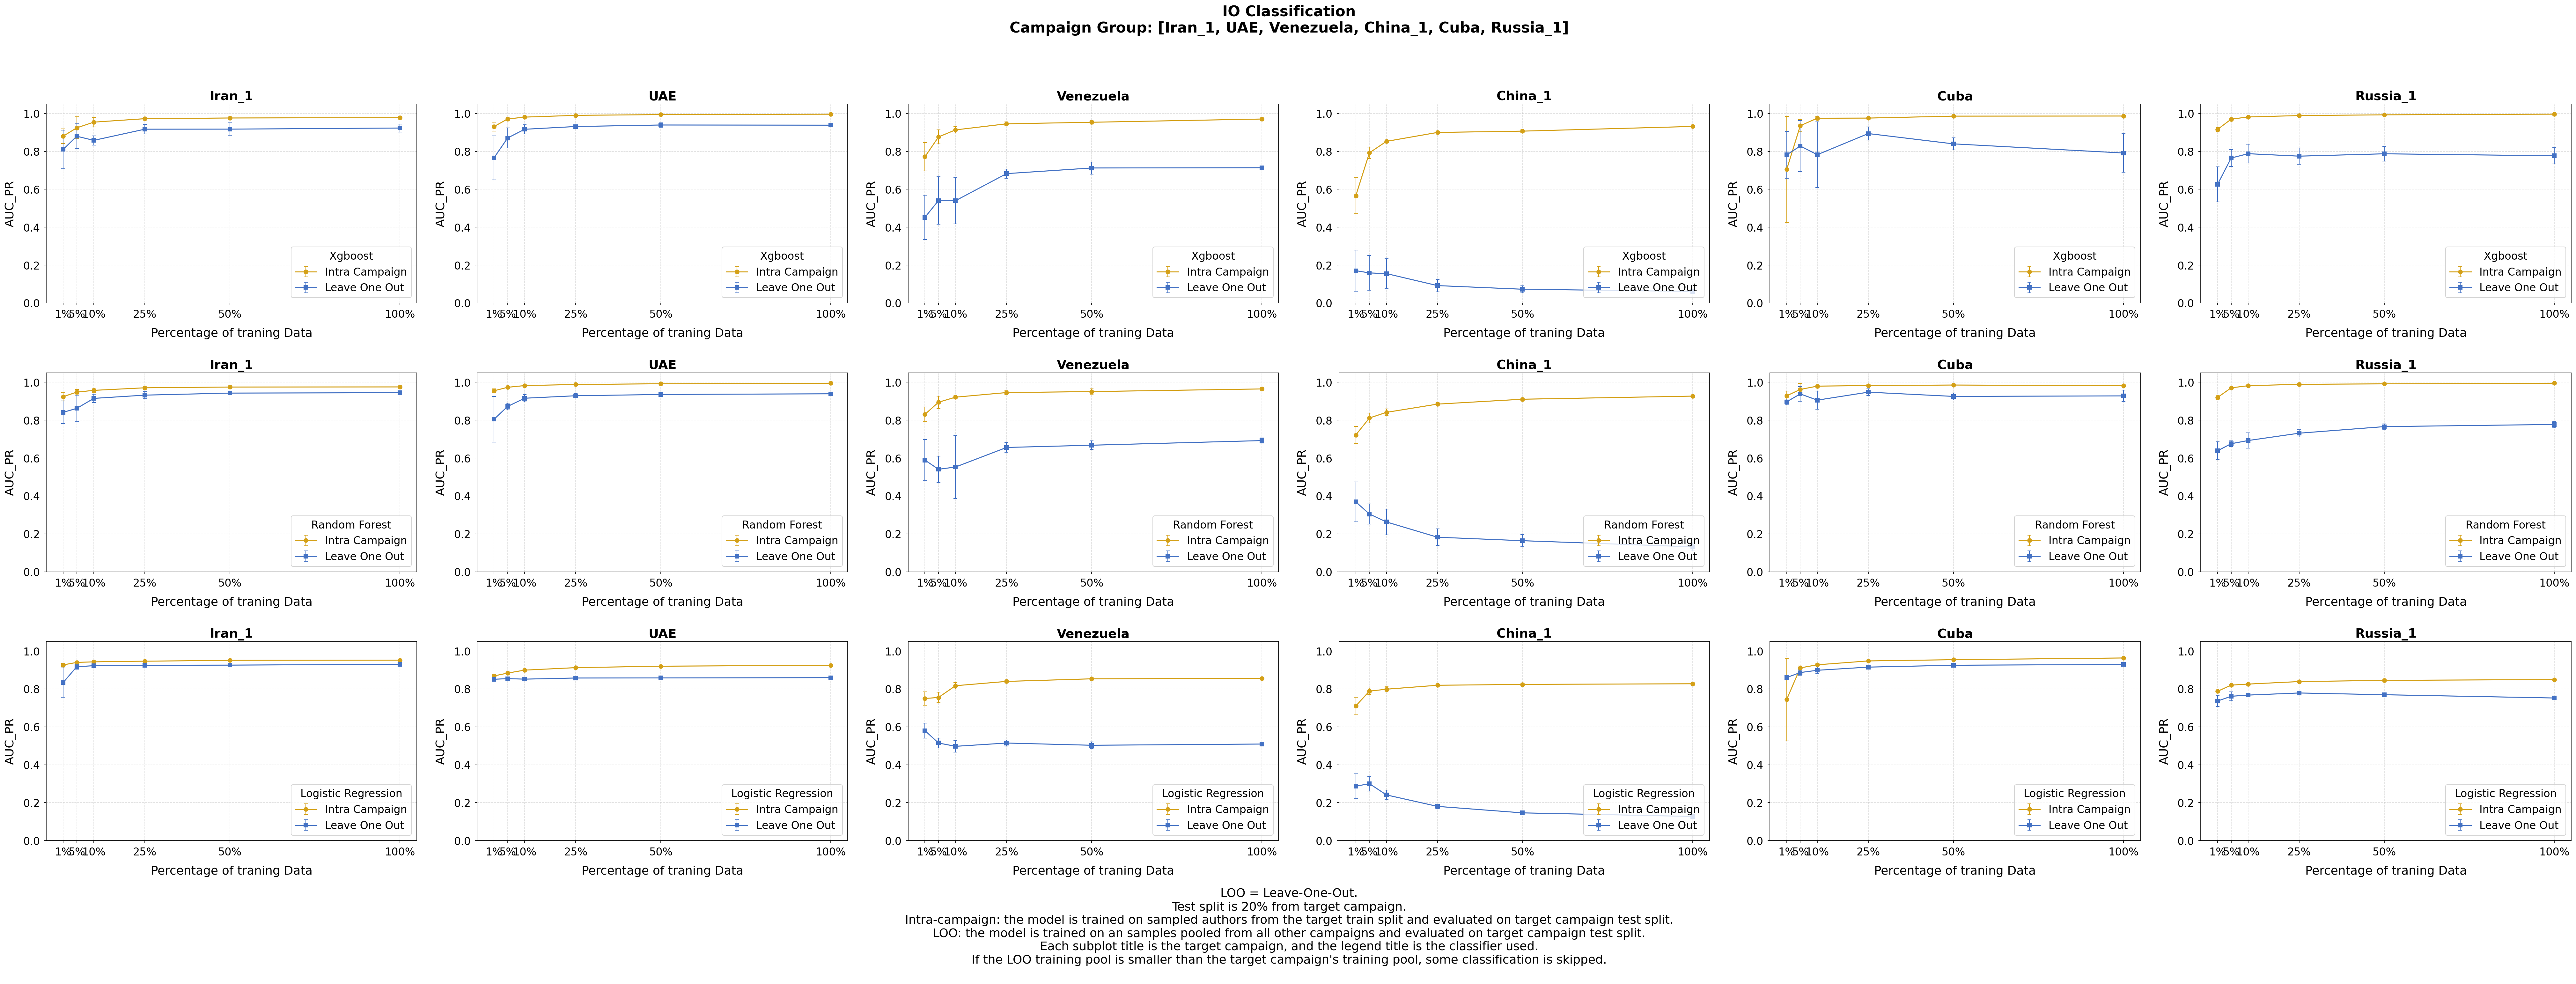

2026-08-18 09:08:46 | Saved plot → ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_strategy_comparison_f1.png


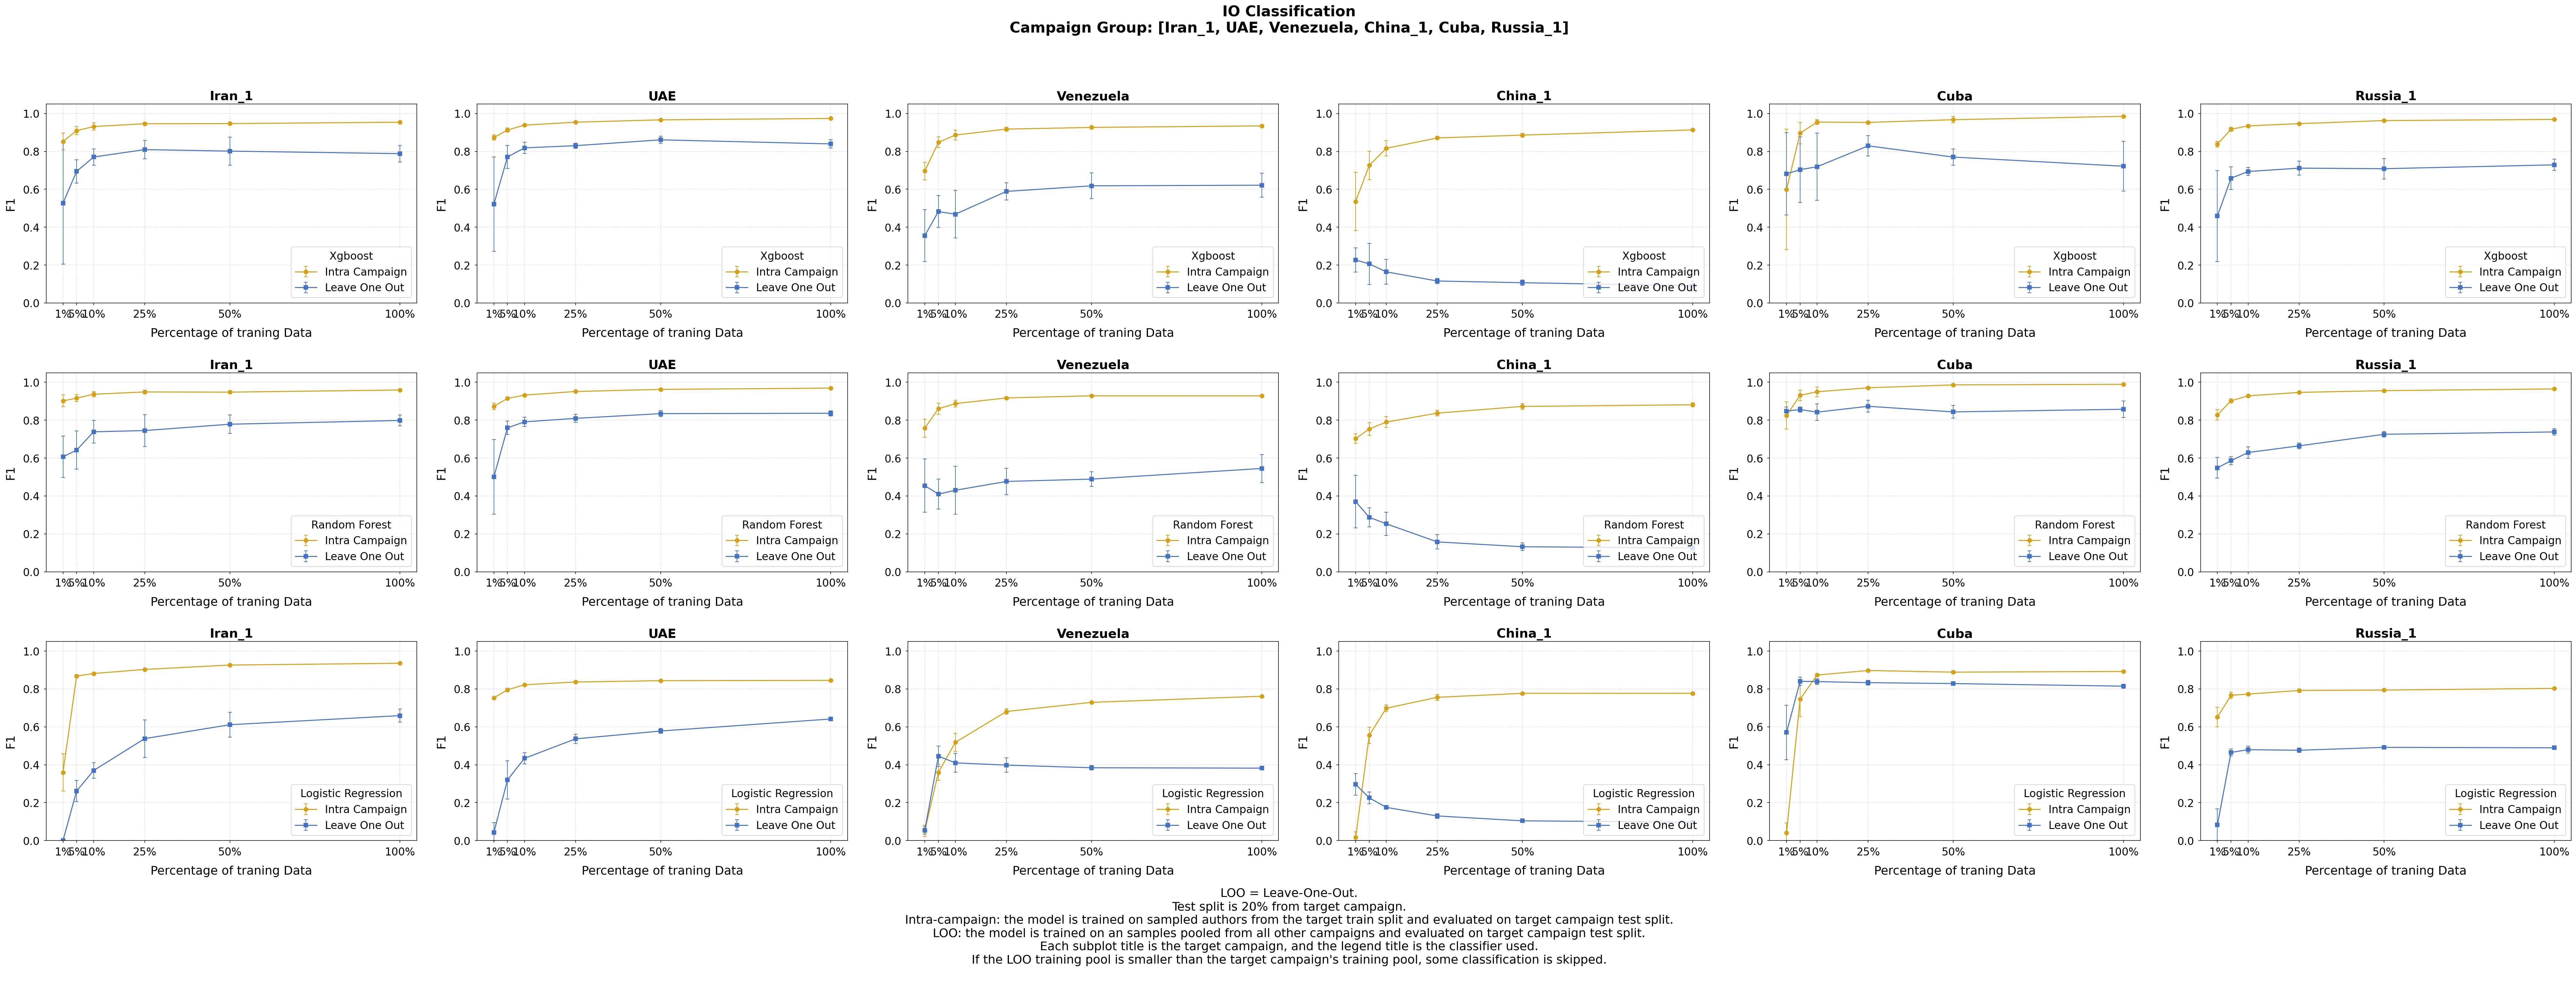

2026-08-18 09:09:11 | Saved plot → ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_strategy_comparison_recall.png


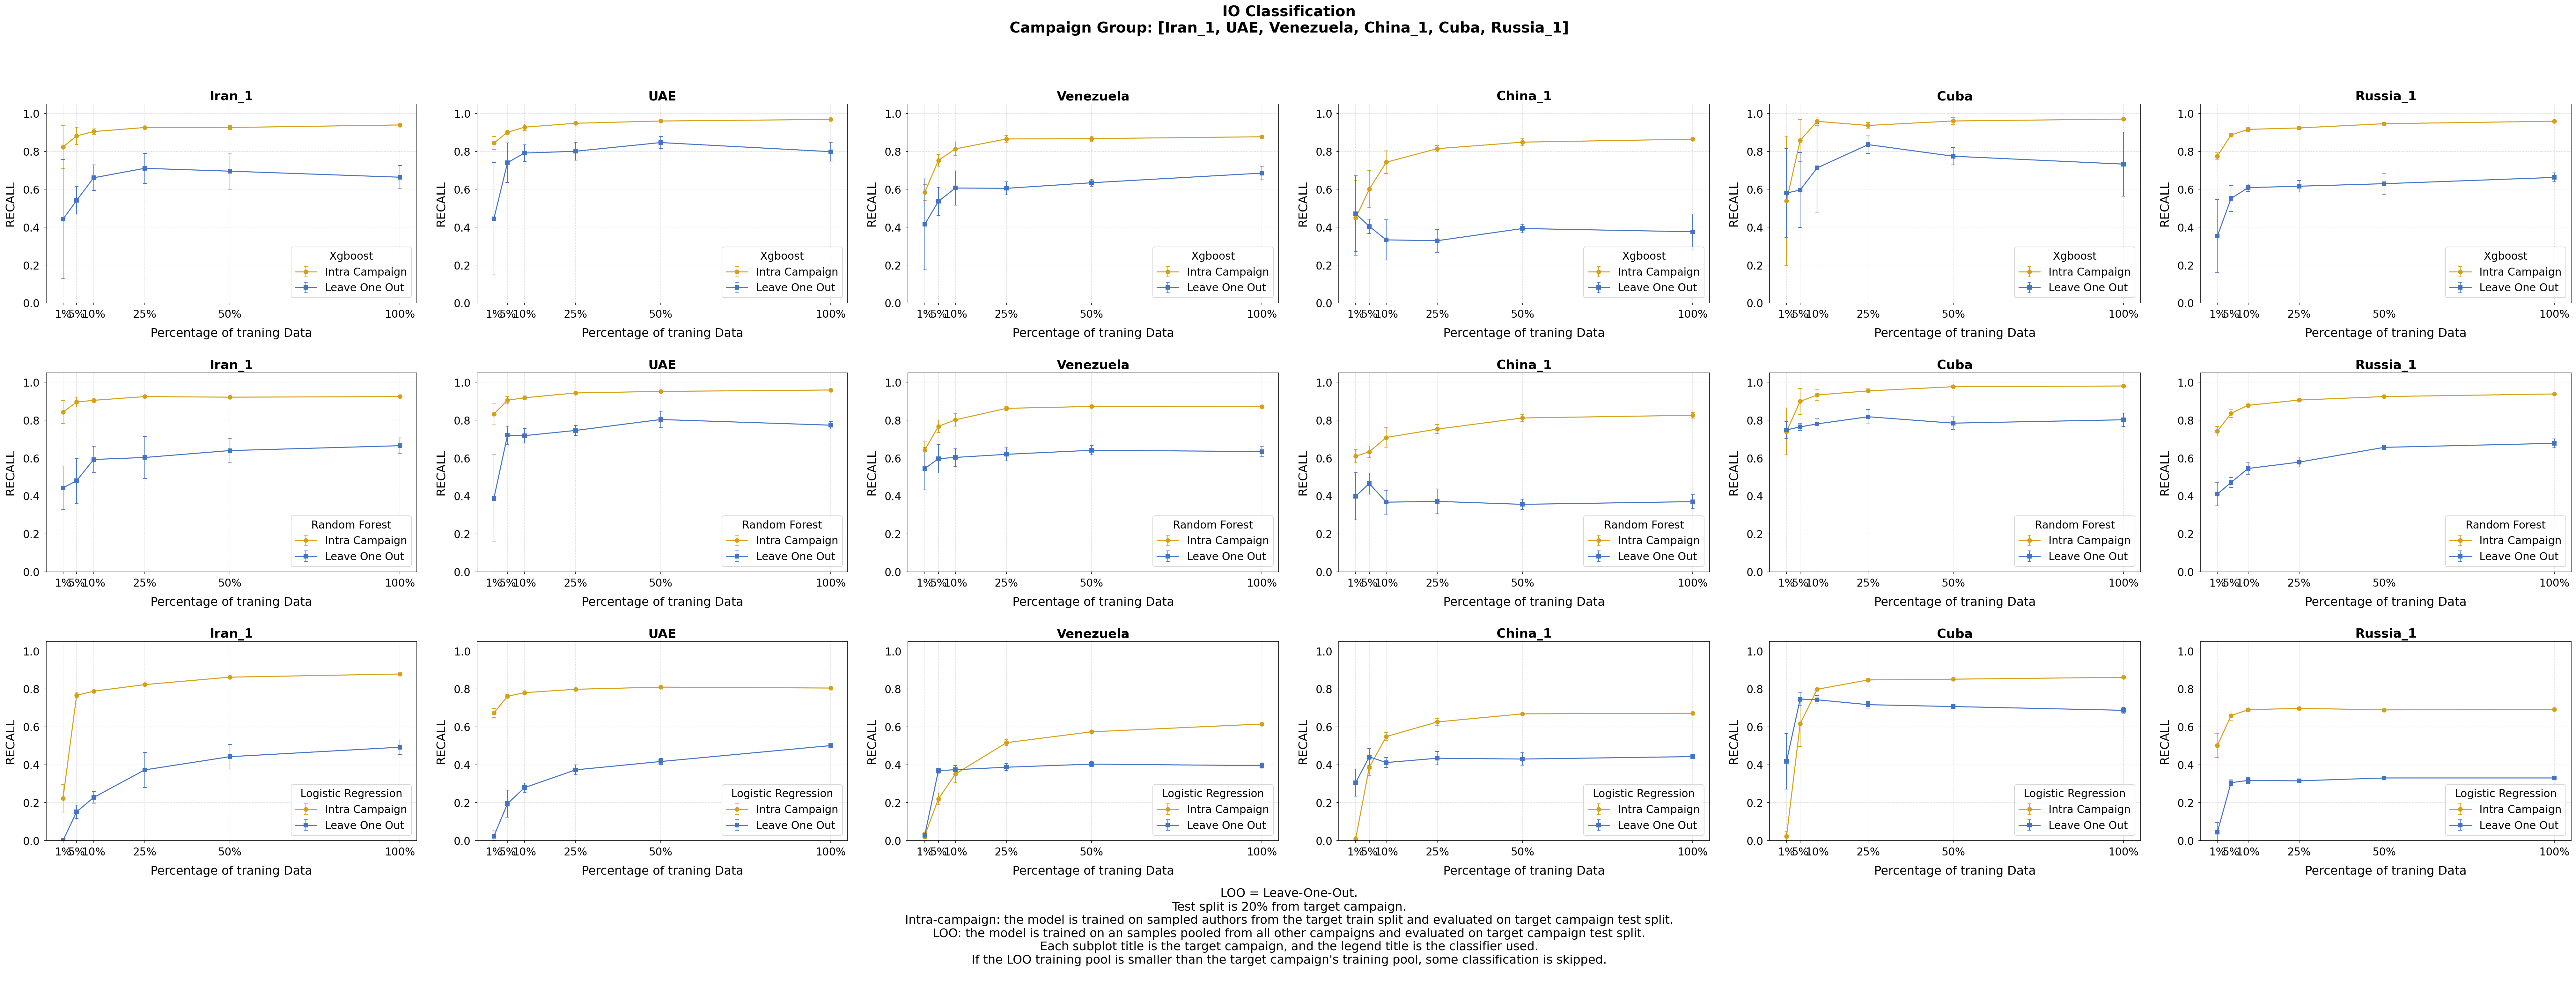

2026-08-18 09:09:35 | Saved plot → ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_strategy_comparison_precision.png


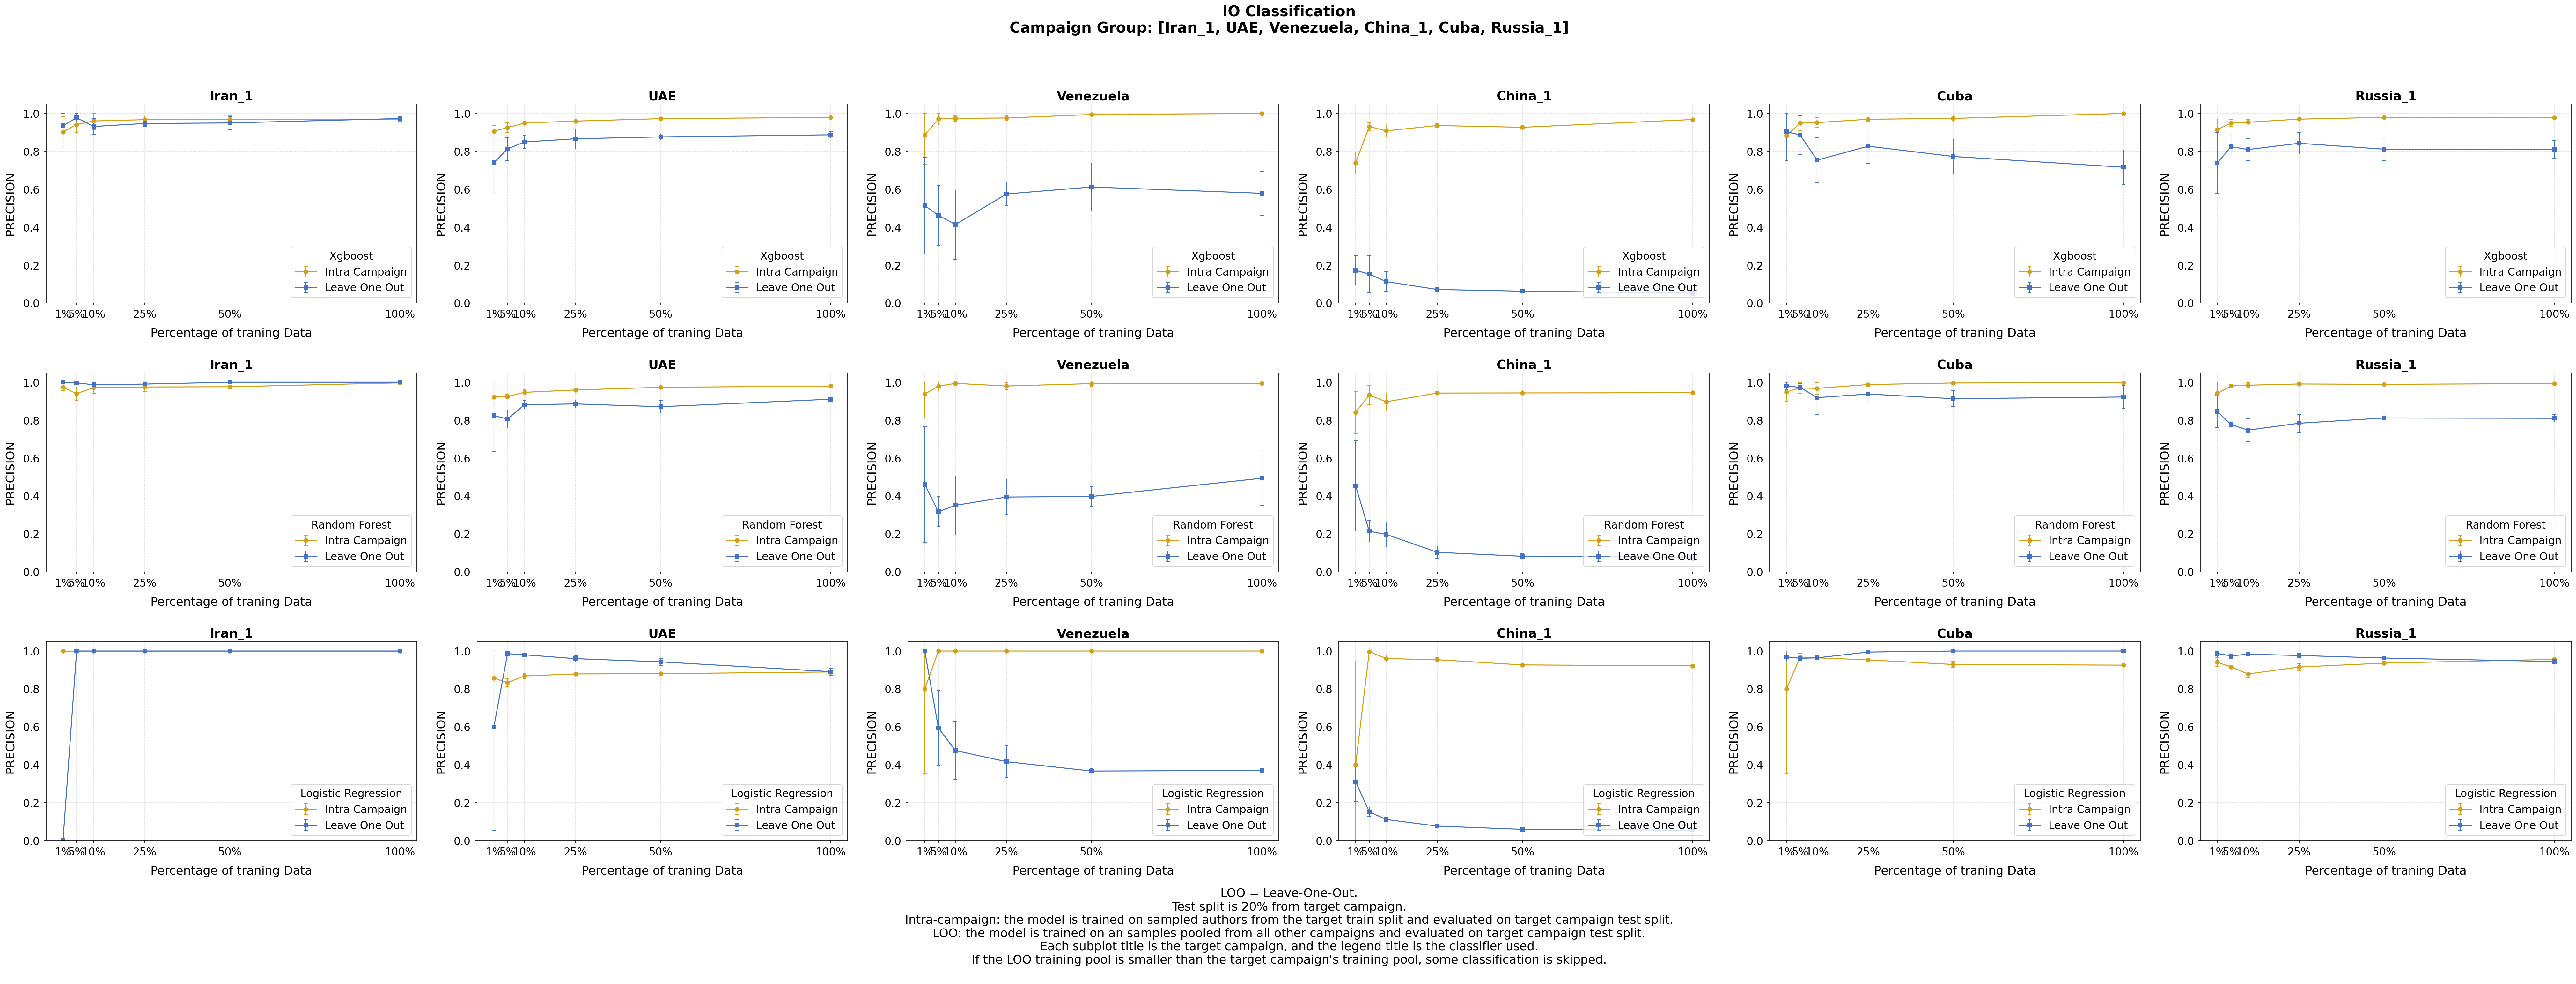

2026-08-18 09:09:38 | Pipeline completed.


In [14]:
if not results_df.empty:
    metrics_to_plot = [
        "auc_roc",
        "auc_pr",
        "f1",
        "recall",
        "precision",
    ]
    for metric in metrics_to_plot:
        plot_cross_campaign_performance(
            df_results=results_df,
            metric=metric,
            output_dir=output_path,
        )

write_report("Pipeline completed.")